In [1]:
import os
import platform
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl

from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm



In [2]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
pl.seed_everything(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Global seed set to 42


In [3]:
# SEQ_LEN = 200
# BATCH_SIZE = 64
# EMBED_DIM = 128
# DROP_OUT = 0.9
# NUM_WORKERS = 0 if platform.system() == 'Windows' else 4
# N_GCN_LAYERS = 3
# print("os:{}, num-workers:{}".format(platform.system(), NUM_WORKERS))

结果：0.88881

In [4]:
# SEQ_LEN = 200
SEQ_LEN = 92
BATCH_SIZE = 512
EMBED_DIM = 128
DROP_OUT = 0.8
NUM_WORKERS = 0 if platform.system() == 'Windows' else 4
# N_GCN_LAYERS = 3
N_GCN_LAYERS = 0
print("os:{}, num-workers:{}".format(platform.system(), NUM_WORKERS))

os:Linux, num-workers:4


结果：0.88770

### load and process assist12 data

In [5]:
dataset_name = 'assist12'
dataset_path = os.path.join(os.getcwd(), 'dataset', dataset_name)

df = pd.read_csv(os.path.join(dataset_path, "assist.csv"), low_memory=False, encoding="ISO-8859-1").sort_values(by = 'user_id')
df

,user_id,problem_id,skill,problem_type,ms_first_response,attempt_count,correct
1848377,21421,114088,Point Plotting,choose_1,7634,1,1.0
1036327,21421,665276,Addition and Subtraction Integers,algebra,5256,1,1.0
1565263,21421,665243,Addition and Subtraction Integers,algebra,7169,1,1.0
1406035,21421,114117,Point Plotting,choose_1,7890,1,1.0
1509075,21421,114082,Point Plotting,choose_1,6309,1,1.0
...,...,...,...,...,...,...,...
2471080,228213,140002,Complementary and Supplementary Angles,algebra,36756,1,1.0
1796906,228213,143040,Angles on Parallel Lines Cut by a Transversal,algebra,12907,1,1.0
1216151,228213,254199,Interior Angles Triangle,algebra,34254,1,1.0
1498778,228213,139967,Complementary and Supplementary Angles,algebra,10934,1,1.0


In [6]:
key = 'problem_id'

key_q = 'q_idx'
key_s = 's_idx'
key_qt = 'q_type'
key_qd = 'q_diff'
key_ms_first_response = 'ms_first_response'
key_attempts = 'attempt_count'

### problem个数

In [7]:
question_id_dict = dict(zip(df[key].unique(), range(len(df[key].unique()))))
# print(question_id_dict)
N_QUESTION = len(question_id_dict)
N_QUESTION

50988

### skill 个数

In [8]:
skill_id_dict = dict(zip(df['skill'].unique(), range(len(df['skill'].unique()))))
# skill_id_dict
N_SKILL = len(skill_id_dict)
N_SKILL

198

### problem type 个数

In [9]:
question_type_dict = dict(zip(df['problem_type'].unique(), range(len(df['problem_type'].unique()))))
# print(question_type_dict)
N_QUESTION_TYPE = len(question_type_dict)
N_QUESTION_TYPE

6

In [10]:
# question idx
df[key_q] = df[key].map(question_id_dict)
df[key_s] = df['skill'].map(skill_id_dict)
df[key_qt] = df['problem_type'].map(question_type_dict)

### 我们需要将数据进行预处理，每个学生的学习记录利用group by合并为序列。

In [11]:
def generate_group_by_df(df):
    group = df[['user_id', key_q, key_s, key_qt, key_qd,key_ms_first_response, key_attempts, 'correct']].groupby(['user_id']).apply(lambda r: (
            r[key_q].values,
            r[key_s].values,
            r[key_qt].values,
            r[key_qd].values,
            r[key_ms_first_response].values,
            r[key_attempts].values,
            r['correct'].values
            ))
    return group

In [12]:
df_train = pd.read_csv(os.path.join(dataset_path, "train.csv"), low_memory=False, encoding="ISO-8859-1")
df_train

,user_id,q_idx,s_idx,q_type,q_diff,ms_first_response,attempt_count,correct
0,123347.0,25458.0,67.0,0.0,0.931818,0.000058,0.034483,1.0
1,123347.0,34684.0,60.0,0.0,0.734940,0.000071,0.034483,1.0
2,123347.0,628.0,60.0,0.0,0.565217,0.000063,0.034483,1.0
3,123347.0,16890.0,67.0,0.0,0.904762,0.000175,0.034483,1.0
4,123347.0,3451.0,60.0,0.0,0.689655,0.000087,0.034483,1.0
...,...,...,...,...,...,...,...,...
2116779,212403.0,28725.0,94.0,0.0,0.937500,0.000183,0.034483,1.0
2116780,212403.0,11215.0,122.0,0.0,1.000000,0.000120,0.034483,1.0
2116781,212403.0,18272.0,56.0,0.0,0.600000,0.000173,0.103448,0.0
2116782,212403.0,36096.0,117.0,0.0,1.000000,0.000298,0.034483,1.0


In [13]:
df_test = pd.read_csv(os.path.join(dataset_path, "test.csv"), low_memory=False, encoding="ISO-8859-1")
df_test

,user_id,q_idx,s_idx,q_type,q_diff,ms_first_response,attempt_count,correct
0,172581.0,1437.0,1.0,0.0,0.909091,0.000034,0.034483,1.0
1,172581.0,1438.0,4.0,0.0,0.500000,0.000384,0.034483,1.0
2,172581.0,5135.0,53.0,0.0,0.511364,0.000130,0.034483,1.0
3,172581.0,8739.0,4.0,0.0,0.333333,0.000091,0.068966,0.0
4,172581.0,3318.0,4.0,0.0,0.746781,0.001292,0.034483,0.0
...,...,...,...,...,...,...,...,...
513291,137254.0,1818.0,19.0,2.0,0.663093,0.000054,0.034483,1.0
513292,137254.0,2084.0,16.0,1.0,0.619658,0.000063,0.034483,0.0
513293,137254.0,15114.0,41.0,0.0,0.892045,0.000102,0.034483,1.0
513294,137254.0,8279.0,62.0,0.0,0.408000,0.000065,0.034483,1.0


In [14]:
2116784 / 513296 # train dataset : test dataset = 80% : 20%

4.123905115177208

In [15]:
train = generate_group_by_df(df_train)
train

user_id
21421.0     ([42053.0, 43935.0, 12325.0, 3331.0, 14133.0, ...
24586.0     ([1742.0, 14412.0, 3609.0, 24416.0, 12314.0, 9...
26046.0     ([16744.0, 22485.0, 22913.0, 914.0, 5048.0, 23...
61394.0     ([0.0, 1.0, 2.0, 4317.0, 6008.0, 6558.0, 3112....
69885.0     ([21155.0, 27198.0, 30905.0, 12918.0], [130.0,...
                                  ...                        
228204.0    ([9068.0, 16588.0, 5606.0, 5468.0, 1882.0, 240...
228209.0    ([1999.0, 25619.0, 9507.0, 19660.0, 15674.0, 1...
228210.0    ([15168.0, 131.0, 1512.0, 4730.0, 25797.0, 140...
228211.0    ([2566.0, 20851.0, 14135.0, 6586.0, 18836.0, 8...
228213.0    ([18184.0, 2377.0, 26948.0, 24676.0, 3947.0, 5...
Length: 23067, dtype: object

In [16]:
test = generate_group_by_df(df_test)
test

user_id
52535.0     ([7989.0, 29838.0, 1747.0, 36724.0, 23334.0, 3...
70190.0     ([26897.0, 29355.0, 43585.0, 22963.0, 45791.0,...
78401.0     ([4.0, 3919.0, 3027.0, 4319.0, 2097.0, 7735.0,...
82852.0     ([14781.0, 4463.0, 26340.0, 13751.0, 20020.0, ...
83952.0     ([6583.0, 18172.0, 4186.0, 11803.0, 7579.0, 62...
                                  ...                        
228146.0    ([16805.0, 13089.0, 39101.0], [131.0, 93.0, 33...
228149.0    ([13170.0, 977.0, 10879.0], [62.0, 87.0, 48.0]...
228150.0    ([10881.0, 841.0], [50.0, 37.0], [0.0, 2.0], [...
228157.0    ([7733.0, 31805.0, 24684.0, 28180.0, 40841.0, ...
228175.0    ([32492.0, 17150.0, 28290.0, 35556.0, 1190.0, ...
Length: 5767, dtype: object

In [17]:
len_list = [len(train.iloc[i][0]) for i in range(len(train))]
print(np.mean(len_list))

91.76676637620844


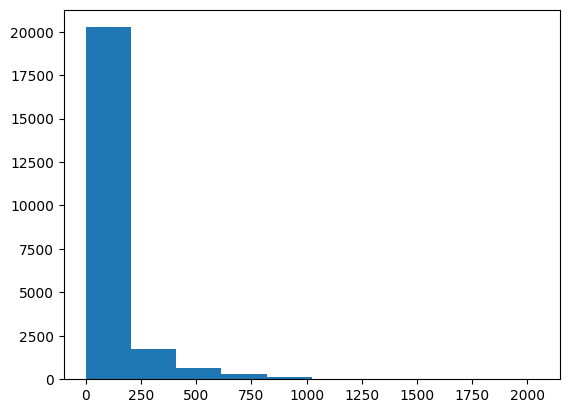

In [18]:
import matplotlib.pyplot as plt
plt.hist(len_list)
plt.show()

In [19]:
23067 + 5767 # user 个数

28834

In [20]:
N_QUERY_FEATURES = len(train.iloc[0])-1
print("N_QUERY_FEATURES:{}".format(N_QUERY_FEATURES))

N_QUERY_FEATURES:6


###  assist12 dataset
处理方式跟assist09方法一样

In [21]:
from data_loader.assist09 import Assist09Dataset

# train, val = train_test_split(group, test_size=0.2)
train_dataset = Assist09Dataset(train, N_QUESTION, SEQ_LEN)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

test_dataset = Assist09Dataset(test, N_QUESTION, SEQ_LEN)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [22]:
train_dataset[2][2]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3, 13, 13, 13, 13,
       13,  3, 13,  3, 13, 13])

In [23]:
print(len(train_dataset), len(test_dataset))
print(len(train_dataloader), len(test_dataloader))

23067 5767
46 12


In [24]:
23067 / 361 # batch_size = 64

63.89750692520776

### load birepart data

In [25]:
from utils.bipartited_data import load_bipartitedata
df_edge = pd.read_table(os.path.join(dataset_path, 'edge_list.dat'), sep='\t')
gcn_data, q_rev_dict, s_rev_dict, q_dict, s_dict = load_bipartitedata(df_edge)
gcn_data = gcn_data.to("cuda")

In [26]:
# from model.proposed import MYModule

# import warnings
# warnings.filterwarnings('ignore')

# # TODO 测试一下属性特征
# # N_QUERY_FEATURES = 5

# model = MYModule(
#     n_question=N_QUESTION,
#     n_skill=N_SKILL,
#     n_qtype=N_QUESTION_TYPE,
#     max_seq=SEQ_LEN,
#     embed_dim=EMBED_DIM,
#     n_query_features=N_QUERY_FEATURES,
#     n_gcn_layers=N_GCN_LAYERS,
#     gcn_data=gcn_data,
#     dropout=DROP_OUT,
#     new_att=False
# )
# print(model)

In [27]:
from model.brikt26 import MYModule

import warnings
warnings.filterwarnings('ignore')

# TODO 测试一下属性特征
# N_QUERY_FEATURES = 5

model = MYModule(
    n_question=N_QUESTION,
    n_skill=N_SKILL,
    n_qtype=N_QUESTION_TYPE,
    max_seq=SEQ_LEN,
    embed_dim=EMBED_DIM,
    n_query_features=N_QUERY_FEATURES,
    n_gcn_layers=N_GCN_LAYERS,
    gcn_data=gcn_data,
    dropout=DROP_OUT,
    new_att=True
)
print(model)

50988 198 6 92 128 6 BipartiteData(edge_index_q2s=[2, 50988], edge_index_s2q=[2, 50988], num_q=50988, num_s=198)
MYModule(
  (loss): BCEWithLogitsLoss()
  (model): MYMODEL(
    (embedding): Embedding(101977, 128)
    (qt_embedding): Embedding(6, 128)
    (diff_embedding): Linear(in_features=1, out_features=128, bias=True)
    (ms_first_response_embedding): Linear(in_features=1, out_features=128, bias=True)
    (attempt_count_embedding): Linear(in_features=1, out_features=128, bias=True)
    (combine_q_embedding_q): Linear(in_features=512, out_features=128, bias=True)
    (q_feature_layer_norm_q): LayerNorm((91, 128), eps=1e-05, elementwise_affine=True)
    (combine_q_embedding_x): Linear(in_features=384, out_features=128, bias=True)
    (q_feature_layer_norm_x): LayerNorm((91, 128), eps=1e-05, elementwise_affine=True)
    (gcn): LightGCNStack(
      (convs): ModuleList()
      (embed_q): Embedding(50988, 128)
      (embed_s): Embedding(198, 128)
    )
    (multi_att): MultiHeadAttentio

In [28]:
# from model.brikt26_no_sideinformation import MYModule

# import warnings
# warnings.filterwarnings('ignore')

# # TODO 测试一下属性特征
# # N_QUERY_FEATURES = 5

# model = MYModule(
#     n_question=N_QUESTION,
#     n_skill=N_SKILL,
#     n_qtype=N_QUESTION_TYPE,
#     max_seq=SEQ_LEN,
#     embed_dim=EMBED_DIM,
#     n_query_features=2,
#     n_gcn_layers=N_GCN_LAYERS,
#     gcn_data=gcn_data,
#     dropout=DROP_OUT,
#     new_att=False
# )
# print(model)

In [29]:
checkpoint_callback = pl.callbacks.ModelCheckpoint(save_top_k=1, verbose=True, monitor='v_auc', mode='max')

In [30]:
patience = 6 if N_QUERY_FEATURES == 6 else 3

In [31]:
trainer = pl.Trainer(
    gpus=1, 
    max_epochs=200, 
    auto_lr_find=True, 
    callbacks=[checkpoint_callback, EarlyStopping(monitor="v_auc", mode="max", patience=6)]
)
print("patience:{}".format(patience))

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


patience:6


### train

In [32]:
trainer.fit(model=model, train_dataloaders=train_dataloader,val_dataloaders=test_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params
--------------------------------------------
0 | loss  | BCEWithLogitsLoss | 0     
1 | model | MYMODEL           | 19.9 M
--------------------------------------------
19.9 M    Trainable params
0         Non-trainable params
19.9 M    Total params
79.471    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Epoch 0, global step 46: 'v_auc' reached 0.73232 (best 0.73232), saving model to '/home/czy/KT/BRIKT/lightning_logs/version_158/checkpoints/epoch=0-step=46.ckpt' as top 1


...

Epoch 20, global step 966: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 21, global step 1012: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 22, global step 1058: 'v_auc' was not in top 1
